# 🌊 FloodShield BD — Sen1Floods11 Real SAR Training (FIXED)
### U-Net trained on REAL Sentinel-1 satellite data (446 hand-labeled chips)
**Dataset:** Sen1Floods11 (Bonafilia et al., CVPR 2020) — 11 real flood events, 6 continents

---
### Bugs fixed in this version:
| # | Bug | Fix |
|---|-----|-----|
| 1 | `import os` was AFTER `os.makedirs` (NameError on run) | Merged imports into Cell 1 before any config |
| 2 | `matplotlib.use('Agg')` broke inline display in Colab | Removed — Colab uses its own inline backend |
| 3 | `import shutil` duplicated inside `download_dataset()` | Removed inner import — top-level import used |
| 4 | `copytree` to Drive crashed on re-run (files exist) | Added `shutil.copy2` loop that skips existing files |
| 5 | `load_geotiff` caught `ImportError` for rasterio I/O errors | Changed to `except Exception` to catch `RasterioIOError` |
| 6 | `tile_image` assumed 3D array — crashed on 2D input | Added shape guard to ensure (bands,H,W) before tiling |
| 7 | `np.isnan()` failed on int16 label arrays (TypeError) | Cast to float32 before isnan check |
| 8 | `weighted_bce_dice_loss` used fragile shape slice `[:,:,:,0]` | Used `tf.squeeze` for version-safe shape handling |
| 9 | Training chart cell crashed if training was skipped | Added `os.path.exists` guard |
|10 | `evaluate_model` crashed on empty test set | Added early-exit guard when `len(X_test) == 0` |
|11 | Overlay boolean array not explicitly cast to float | Added `.astype(np.float32)` for safe imshow |
|12 | Variable name `cm` shadowed sklearn `confusion_matrix` | Renamed to `cm_result` throughout evaluate_model |

**Run order:** Cell 1 → 2 → 3 → 4 → 5 → 6 → 7 → 8 → 9 → 10

## Cell 1 — Install packages & imports
> All imports are here so every later cell can use them safely.

In [1]:
# Install
!pip install tensorflow scikit-learn matplotlib numpy rasterio gcsfs --quiet

# FIX #1: ALL imports here — before any cell that uses os, shutil, etc.
import os, sys, json, glob, itertools, shutil
from datetime import datetime
import numpy as np

# FIX #2: Do NOT call matplotlib.use('Agg') in Colab — it breaks inline display.
# Colab sets its own backend automatically.
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_curve, auc, precision_recall_curve
)

print(f'TensorFlow : {tf.__version__}')
print(f'NumPy      : {np.__version__}')
print('All imports OK.')

TensorFlow : 2.19.0
NumPy      : 2.0.2
All imports OK.


## Cell 2 — Mount Google Drive

In [2]:
from google.colab import drive
drive.mount('/content/drive')

DRIVE_BASE   = '/content/drive/MyDrive/FloodShield_Sen1'
DRIVE_DATA   = os.path.join(DRIVE_BASE, 'sen1floods11_data')
DRIVE_MODELS = os.path.join(DRIVE_BASE, 'models')
DRIVE_EVAL   = os.path.join(DRIVE_BASE, 'evaluation')

LOCAL_DATA   = '/content/sen1floods11_data'
LOCAL_MODELS = '/content/models'
LOCAL_EVAL   = '/content/evaluation'

for d in [DRIVE_BASE, DRIVE_DATA, DRIVE_MODELS, DRIVE_EVAL,
          LOCAL_DATA, LOCAL_MODELS, LOCAL_EVAL]:
    os.makedirs(d, exist_ok=True)

print('Drive mounted.')
print(f'Saving to: {DRIVE_BASE}')

Mounted at /content/drive
Drive mounted.
Saving to: /content/drive/MyDrive/FloodShield_Sen1


## Cell 3 — Configuration

In [3]:
IMAGE_SIZE   = 64
BATCH_SIZE   = 32
EPOCHS       = 50
LR           = 1e-3
SAR_SHIFT    = 35.0   # (dB + 35) / 35
FLOOD_WEIGHT = 6.0    # flood pixel penalty multiplier for loss

GCS_S1_HAND    = 'gs://sen1floods11/v1.1/data/flood_events/HandLabeled/S1Hand'
GCS_LABEL_HAND = 'gs://sen1floods11/v1.1/data/flood_events/HandLabeled/LabelHand'
GCS_SPLITS     = 'gs://sen1floods11/v1.1/splits/flood_handlabeled'

S1_DIR     = os.path.join(LOCAL_DATA, 'S1Hand')
LABEL_DIR  = os.path.join(LOCAL_DATA, 'LabelHand')
SPLITS_DIR = os.path.join(LOCAL_DATA, 'splits')
MODEL_PATH = os.path.join(LOCAL_MODELS, 'flood_best.keras')

for d in [S1_DIR, LABEL_DIR, SPLITS_DIR]:
    os.makedirs(d, exist_ok=True)

print('Configuration ready.')

Configuration ready.


## Cell 4 — Download Sen1Floods11 dataset
Downloads ~2–3 GB from Google's public bucket. Skips if already cached in Drive.
Takes 5–15 min on first run.

In [4]:
def _safe_copy_dir(src_dir, dst_dir):
    """FIX #4: Copy files individually, skipping ones that already exist.
    Avoids FileExistsError from shutil.copytree on re-runs."""
    os.makedirs(dst_dir, exist_ok=True)
    copied = 0
    for fname in os.listdir(src_dir):
        src = os.path.join(src_dir, fname)
        dst = os.path.join(dst_dir, fname)
        if os.path.isfile(src) and not os.path.exists(dst):
            shutil.copy2(src, dst)
            copied += 1
    return copied

def download_dataset():
    n_s1 = len(glob.glob(f'{S1_DIR}/*.tif'))
    n_lb = len(glob.glob(f'{LABEL_DIR}/*.tif'))
    if n_s1 > 0 and n_lb > 0:
        print(f'[DATA] Already local: {n_s1} S1, {n_lb} labels')
        return

    # Check Drive cache first
    drive_s1    = os.path.join(DRIVE_DATA, 'S1Hand')
    drive_label = os.path.join(DRIVE_DATA, 'LabelHand')
    drive_n = len(glob.glob(f'{drive_s1}/*.tif')) if os.path.exists(drive_s1) else 0
    if drive_n > 0:
        print(f'[DATA] Found {drive_n} files in Drive cache. Copying to local...')
        _safe_copy_dir(drive_s1,    S1_DIR)
        _safe_copy_dir(drive_label, LABEL_DIR)
        drive_splits = os.path.join(DRIVE_DATA, 'splits')
        if os.path.exists(drive_splits):
            _safe_copy_dir(drive_splits, SPLITS_DIR)
        print('[DATA] Copied from Drive cache. Ready.')
        return

    print('[DOWNLOAD] Starting (~2-3 GB, 5-15 min)...')
    import subprocess
    try:
        for gcs, local, label in [
            (GCS_S1_HAND,    S1_DIR,    'S1 images'),
            (GCS_LABEL_HAND, LABEL_DIR, 'Labels'),
            (GCS_SPLITS,     SPLITS_DIR,'Splits'),
        ]:
            print(f'  Downloading {label}...')
            r = subprocess.run(['gsutil','-m','rsync','-r', gcs, local],
                               capture_output=True, text=True,
                               timeout=1200 if 'S1' in label else 300)
            if r.returncode != 0 and 'S1' in label:
                raise RuntimeError(r.stderr[:300])
            elif r.returncode != 0:
                print(f'    Warning: {label} download failed (non-fatal)')
    except (FileNotFoundError, RuntimeError) as e:
        print(f'  gsutil failed: {e}\n  Trying gcsfs...')
        try:
            import gcsfs
            fs = gcsfs.GCSFileSystem(token='anon')
            for gcs_path, local_dir, label in [
                ('sen1floods11/v1.1/data/flood_events/HandLabeled/S1Hand',    S1_DIR,    'S1'),
                ('sen1floods11/v1.1/data/flood_events/HandLabeled/LabelHand', LABEL_DIR, 'Labels'),
            ]:
                files = [f for f in fs.ls(gcs_path) if f.endswith('.tif')]
                print(f'  {len(files)} {label} files found')
                for i, fpath in enumerate(files):
                    local = os.path.join(local_dir, os.path.basename(fpath))
                    if not os.path.exists(local): fs.get(fpath, local)
                    if (i+1) % 50 == 0: print(f'    [{i+1}/{len(files)}]')
        except ImportError:
            print('ERROR: !pip install gcsfs  then re-run this cell.')
            raise

    n_s1 = len(glob.glob(f'{S1_DIR}/*.tif'))
    n_lb = len(glob.glob(f'{LABEL_DIR}/*.tif'))
    print(f'\n[DATA] Done: {n_s1} S1 images, {n_lb} labels')

    # FIX #4: Cache to Drive using safe copy (won't fail on re-run)
    print('[DRIVE] Caching to Drive...')
    _safe_copy_dir(S1_DIR,    os.path.join(DRIVE_DATA,'S1Hand'))
    _safe_copy_dir(LABEL_DIR, os.path.join(DRIVE_DATA,'LabelHand'))
    if os.path.exists(SPLITS_DIR):
        _safe_copy_dir(SPLITS_DIR, os.path.join(DRIVE_DATA,'splits'))
    print('[DRIVE] Cached. Future runs will use Drive.')

download_dataset()

[DOWNLOAD] Starting (~2-3 GB, 5-15 min)...

[DATA] Done: 446 S1 images, 446 labels
[DRIVE] Caching to Drive...
[DRIVE] Cached. Future runs will use Drive.


## Cell 5 — Load, tile and normalize
Reads each 512×512 GeoTIFF → tiles to 64×64 → normalizes.
Discards tiles with >30% no-data. Uses official splits if available.

In [5]:
def load_geotiff(filepath):
    # FIX #5: catch Exception (not just ImportError) for rasterio I/O errors
    try:
        import rasterio
        with rasterio.open(filepath) as src:
            return src.read()  # (bands, H, W)
    except Exception:  # RasterioIOError, corrupt file, etc.
        try:
            from osgeo import gdal
            ds = gdal.Open(filepath); arr = ds.ReadAsArray(); ds = None; return arr
        except Exception:
            import tifffile; return tifffile.imread(filepath)

def tile_image(image, mask, tile_size=IMAGE_SIZE):
    # FIX #6: guard against 2D arrays from rasterio
    if image.ndim == 2:
        image = image[np.newaxis, :, :]  # (1,H,W)
    if image.shape[0] == 1:
        image = np.concatenate([image, image], axis=0)  # duplicate to (2,H,W)
    tiles = []
    h, w = image.shape[1], image.shape[2]
    for y in range(0, h - tile_size + 1, tile_size):
        for x in range(0, w - tile_size + 1, tile_size):
            img_t  = image[:, y:y+tile_size, x:x+tile_size]
            mask_t = mask[y:y+tile_size, x:x+tile_size]
            valid  = (mask_t >= 0).sum()
            if valid < mask_t.size * 0.7: continue
            mask_t = np.clip(mask_t, 0, 1)
            tiles.append((img_t, mask_t))
    return tiles

def load_sen1floods11():
    print('[LOAD] Reading Sen1Floods11 GeoTIFFs...')
    train_ids = valid_ids = test_ids = None
    train_csv = os.path.join(SPLITS_DIR, 'flood_train_data.csv')
    valid_csv = os.path.join(SPLITS_DIR, 'flood_valid_data.csv')
    test_csv  = os.path.join(SPLITS_DIR, 'flood_test_data.csv')
    if os.path.exists(train_csv):
        def read_ids(fp):
            with open(fp) as f:
                return set(os.path.splitext(os.path.basename(
                    l.strip().split(',')[0]))[0]
                    for l in f if l.strip() and not l.startswith('#'))
        train_ids = read_ids(train_csv)
        valid_ids = read_ids(valid_csv)
        test_ids  = read_ids(test_csv)
        print(f'  Official splits — train:{len(train_ids)} val:{len(valid_ids)} test:{len(test_ids)}')
    s1_files = sorted(glob.glob(os.path.join(S1_DIR, '*.tif')))
    print(f'  Found {len(s1_files)} S1 files')
    if len(s1_files) == 0:
        raise RuntimeError('No .tif files found in S1_DIR. Check Cell 4 download.')
    train_tiles, val_tiles, test_tiles = [], [], []
    skipped = 0
    for i, s1_path in enumerate(s1_files):
        fname = os.path.basename(s1_path)
        for lname in [fname.replace('_S1Hand','_LabelHand'),
                      fname.replace('S1','Label'), fname]:
            lpath = os.path.join(LABEL_DIR, lname)
            if os.path.exists(lpath): break
        else:
            skipped += 1; continue
        try:
            s1  = load_geotiff(s1_path)
            lbl = load_geotiff(lpath)
            # FIX #6: shape guards
            if s1.ndim == 2:
                s1 = np.stack([s1, s1], axis=0)
            if s1.shape[0] > 2:
                s1 = s1[:2]
            if lbl.ndim == 3:
                lbl = lbl[0]
            # FIX #7: cast to float BEFORE np.isnan — avoids TypeError on int16 arrays
            s1  = s1.astype(np.float32)
            lbl = lbl.astype(np.float32)
            if np.isnan(s1).all() or np.isnan(lbl).all():
                skipped += 1; continue
            s1  = np.nan_to_num(s1,  nan=0.0)
            lbl = np.nan_to_num(lbl, nan=-1.0)
            s1_norm = np.clip((s1 + SAR_SHIFT) / SAR_SHIFT, 0, 1).astype(np.float32)
            tiles = tile_image(s1_norm, lbl, IMAGE_SIZE)
            fid = os.path.splitext(fname)[0]
            if train_ids is not None:
                if   fid in train_ids or any(fid in t for t in train_ids): train_tiles.extend(tiles)
                elif fid in valid_ids or any(fid in t for t in valid_ids): val_tiles.extend(tiles)
                elif fid in test_ids  or any(fid in t for t in test_ids):  test_tiles.extend(tiles)
                else: train_tiles.extend(tiles)
            else:
                train_tiles.extend(tiles)
        except Exception as e:
            print(f'  Warning: {fname}: {e}'); skipped += 1; continue
        if (i+1) % 50 == 0:
            total = len(train_tiles)+len(val_tiles)+len(test_tiles)
            print(f'  [{i+1}/{len(s1_files)}] {total} tiles so far')
    if train_ids is None or len(val_tiles) == 0:
        print('  Creating manual 70/15/15 split...')
        all_t = train_tiles + val_tiles + test_tiles
        np.random.seed(42); idx = np.random.permutation(len(all_t))
        n_tr = int(0.70*len(all_t)); n_va = int(0.15*len(all_t))
        train_tiles = [all_t[i] for i in idx[:n_tr]]
        val_tiles   = [all_t[i] for i in idx[n_tr:n_tr+n_va]]
        test_tiles  = [all_t[i] for i in idx[n_tr+n_va:]]
    def to_arrays(tiles):
        if not tiles:
            return (np.empty((0,IMAGE_SIZE,IMAGE_SIZE,2),dtype=np.float32),
                    np.empty((0,IMAGE_SIZE,IMAGE_SIZE,1),dtype=np.float32))
        X = np.array([t[0].transpose(1,2,0) for t in tiles],dtype=np.float32)
        y = np.array([t[1][:,:,np.newaxis]  for t in tiles],dtype=np.float32)
        return X, y
    X_train,y_train = to_arrays(train_tiles)
    X_val,  y_val   = to_arrays(val_tiles)
    X_test, y_test  = to_arrays(test_tiles)
    print(f'\n  Skipped: {skipped} files')
    for nm, X, y in [('Train',X_train,y_train),('Val',X_val,y_val),('Test',X_test,y_test)]:
        fp = y.mean()*100 if len(y)>0 else 0
        print(f'  {nm:5s}: {X.shape}  flood%: {fp:.1f}%')
    return X_train, y_train, X_val, y_val, X_test, y_test

X_train, y_train, X_val, y_val, X_test, y_test = load_sen1floods11()

[LOAD] Reading Sen1Floods11 GeoTIFFs...
  Official splits — train:252 val:89 test:90
  Found 446 S1 files
  [50/446] 2021 tiles so far
  [100/446] 4346 tiles so far
  [150/446] 7127 tiles so far
  [200/446] 9679 tiles so far
  [250/446] 12412 tiles so far
  [300/446] 15206 tiles so far
  [350/446] 18143 tiles so far
  [400/446] 21053 tiles so far

  Skipped: 1 files
  Train: (14250, 64, 64, 2)  flood%: 9.7%
  Val  : (4839, 64, 64, 2)  flood%: 10.8%
  Test : (4888, 64, 64, 2)  flood%: 12.2%


## Cell 6 — Loss functions, metrics & U-Net model

In [6]:
def dice_coef(y_true, y_pred, smooth=1e-6):
    y_true_f = tf.keras.backend.flatten(y_true)
    y_pred_f = tf.keras.backend.flatten(y_pred)
    inter = tf.keras.backend.sum(y_true_f * y_pred_f)
    return (2.*inter+smooth)/(tf.keras.backend.sum(y_true_f)+tf.keras.backend.sum(y_pred_f)+smooth)

def dice_loss(y_true, y_pred):
    return 1.0 - dice_coef(y_true, y_pred)

def weighted_bce_dice_loss(y_true, y_pred):
    # FIX #8: use tf.squeeze instead of fragile [:,:,:,0] slice
    # Works correctly regardless of whether bce returns (N,H,W) or (N,H,W,1)
    weights = 1.0 + (FLOOD_WEIGHT - 1.0) * y_true          # (N,H,W,1)
    weights = tf.squeeze(weights, axis=-1)                   # (N,H,W)
    bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)  # (N,H,W)
    bce = tf.squeeze(bce) if bce.shape.rank == 4 else bce   # ensure (N,H,W)
    w_bce = tf.reduce_mean(weights * bce)
    return w_bce + dice_loss(y_true, y_pred)

def iou_metric(y_true, y_pred):
    yb = tf.cast(y_pred > 0.5, tf.float32)
    inter = tf.reduce_sum(y_true * yb)
    union = tf.reduce_sum(y_true) + tf.reduce_sum(yb) - inter
    return (inter+1e-6)/(union+1e-6)

CUSTOM_OBJECTS = {
    'dice_coef':dice_coef, 'dice_loss':dice_loss,
    'weighted_bce_dice_loss':weighted_bce_dice_loss,
    'iou_metric':iou_metric
}

def build_unet(input_shape=(IMAGE_SIZE, IMAGE_SIZE, 2)):
    def cb(x, f):
        x = layers.Conv2D(f,3,padding='same',activation='relu',
                          kernel_initializer='he_normal')(x)
        x = layers.BatchNormalization()(x)
        x = layers.Conv2D(f,3,padding='same',activation='relu',
                          kernel_initializer='he_normal')(x)
        x = layers.BatchNormalization()(x)
        return x
    inp = layers.Input(input_shape)
    c1=cb(inp,16); p1=layers.MaxPooling2D(2)(c1)
    c2=cb(p1, 32); p2=layers.MaxPooling2D(2)(c2)
    c3=cb(p2, 64); p3=layers.MaxPooling2D(2)(c3)
    bn=layers.Dropout(0.3)(cb(p3,128))
    u1=layers.Concatenate()([layers.UpSampling2D(2)(bn),c3]); d1=cb(u1,64)
    u2=layers.Concatenate()([layers.UpSampling2D(2)(d1),c2]); d2=cb(u2,32)
    u3=layers.Concatenate()([layers.UpSampling2D(2)(d2),c1]); d3=cb(u3,16)
    return Model(inp, layers.Conv2D(1,1,activation='sigmoid')(d3), name='FloodUNet')

print('Loss functions and model architecture defined.')

Loss functions and model architecture defined.


## Cell 7 — Augment & train
⏱ ~15–30 min on Colab T4 GPU.

> Skip this cell if `flood_best.keras` already exists in your Drive.

[AUGMENT] 4× augmentation...
  Aug train : (57000, 64, 64, 2)  flood%: 9.7%
  Val       : (4839, 64, 64, 2)   flood%: 10.8%
  Parameters: 489,969
[TRAIN] Starting on real Sentinel-1 data...
Epoch 1/50
1782/1782 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.8987 - dice_coef: 0.4751 - iou_metric: 0.4557 - loss: 1.0267
Epoch 1: val_dice_coef improved from None to 0.30518, saving model to /content/models/flood_best.keras

Epoch 1: finished saving model to /content/models/flood_best.keras
1782/1782 ━━━━━━━━━━━━━━━━━━━━ 74s 28ms/step - accuracy: 0.9205 - dice_coef: 0.5432 - iou_metric: 0.4961 - loss: 0.9070 - val_accuracy: 0.8697 - val_dice_coef: 0.3052 - val_iou_metric: 0.2963 - val_loss: 1.0995 - learning_rate: 0.0010
Epoch 2/50
1780/1782 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9363 - dice_coef: 0.6056 - iou_metric: 0.5386 - loss: 0.7964
Epoch 2: val_dice_coef improved from 0.30518 to 0.39441, saving model to /content/models/flood_best.keras

Epoch 2: finished saving model to /co

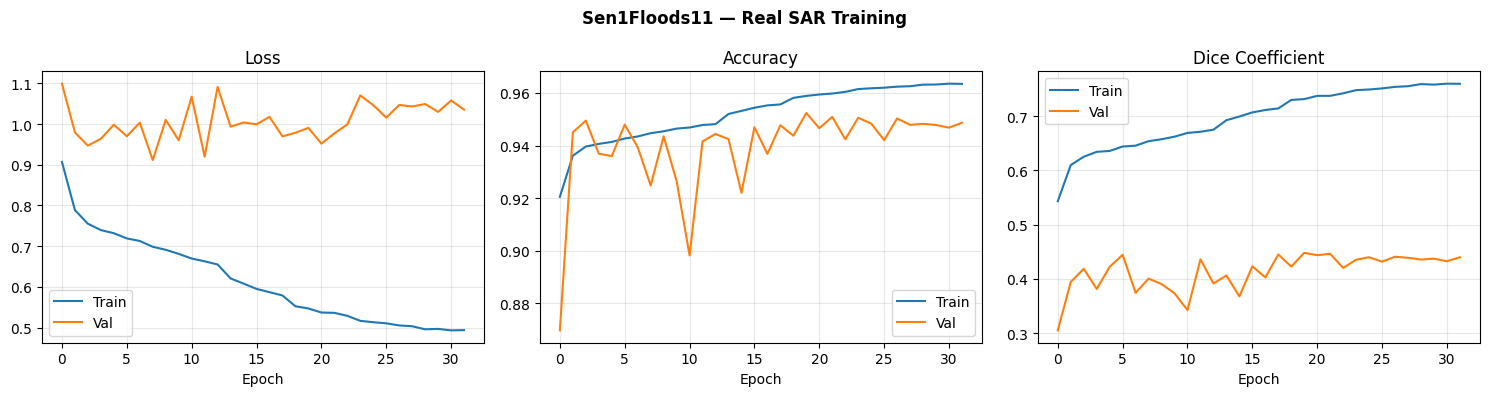


[DONE] Best val Dice: 0.4481
[DRIVE] Models → /content/drive/MyDrive/FloodShield_Sen1/models/


In [7]:
def augment(X, y):
    Xa, ya = [X],[y]
    Xa.append(np.flip(X,axis=2)); ya.append(np.flip(y,axis=2))
    Xa.append(np.flip(X,axis=1)); ya.append(np.flip(y,axis=1))
    Xa.append(np.rot90(X,axes=(1,2))); ya.append(np.rot90(y,axes=(1,2)))
    return np.concatenate(Xa), np.concatenate(ya)

def train_model(X_tr, y_tr, X_va, y_va):
    print('[AUGMENT] 4× augmentation...')
    X_aug, y_aug = augment(X_tr, y_tr)
    idx = np.random.permutation(len(X_aug))
    X_aug, y_aug = X_aug[idx], y_aug[idx]
    print(f'  Aug train : {X_aug.shape}  flood%: {y_aug.mean()*100:.1f}%')
    print(f'  Val       : {X_va.shape}   flood%: {y_va.mean()*100:.1f}%')
    model = build_unet()
    model.compile(
        optimizer=keras.optimizers.Adam(LR),
        loss=weighted_bce_dice_loss,
        metrics=['accuracy', dice_coef, iou_metric]
    )
    print(f'  Parameters: {model.count_params():,}')
    callbacks = [
        ModelCheckpoint(MODEL_PATH, monitor='val_dice_coef', mode='max',
                        save_best_only=True, verbose=1),
        EarlyStopping(monitor='val_dice_coef', mode='max',
                      patience=12, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5,
                          min_lr=1e-7, verbose=1),
    ]
    print('[TRAIN] Starting on real Sentinel-1 data...')
    history = model.fit(
        X_aug, y_aug, batch_size=BATCH_SIZE, epochs=EPOCHS,
        validation_data=(X_va, y_va), callbacks=callbacks, verbose=1
    )
    final_path = os.path.join(LOCAL_MODELS, 'flood_final.keras')
    model.save(final_path)
    # Save to Drive using safe copy
    shutil.copy2(MODEL_PATH, os.path.join(DRIVE_MODELS,'flood_best.keras'))
    shutil.copy2(final_path, os.path.join(DRIVE_MODELS,'flood_final.keras'))
    # FIX #2: No matplotlib.use('Agg') — inline backend active, plot will show below
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for ax, key, title in zip(axes,
            ['loss','accuracy','dice_coef'],
            ['Loss','Accuracy','Dice Coefficient']):
        ax.plot(history.history[key],     label='Train')
        ax.plot(history.history['val_'+key], label='Val')
        ax.set_title(title); ax.legend()
        ax.set_xlabel('Epoch'); ax.grid(alpha=0.3)
    plt.suptitle('Sen1Floods11 — Real SAR Training', fontweight='bold')
    plt.tight_layout()
    chart_path = os.path.join(DRIVE_MODELS,'training_history.png')
    plt.savefig(chart_path, dpi=150, bbox_inches='tight')
    plt.show()   # shows inline in Colab
    plt.close()
    best = max(history.history['val_dice_coef'])
    print(f'\n[DONE] Best val Dice: {best:.4f}')
    print(f'[DRIVE] Models → {DRIVE_MODELS}/')
    return model, history

model, history = train_model(X_train, y_train, X_val, y_val)

### View training history chart (if training was skipped)

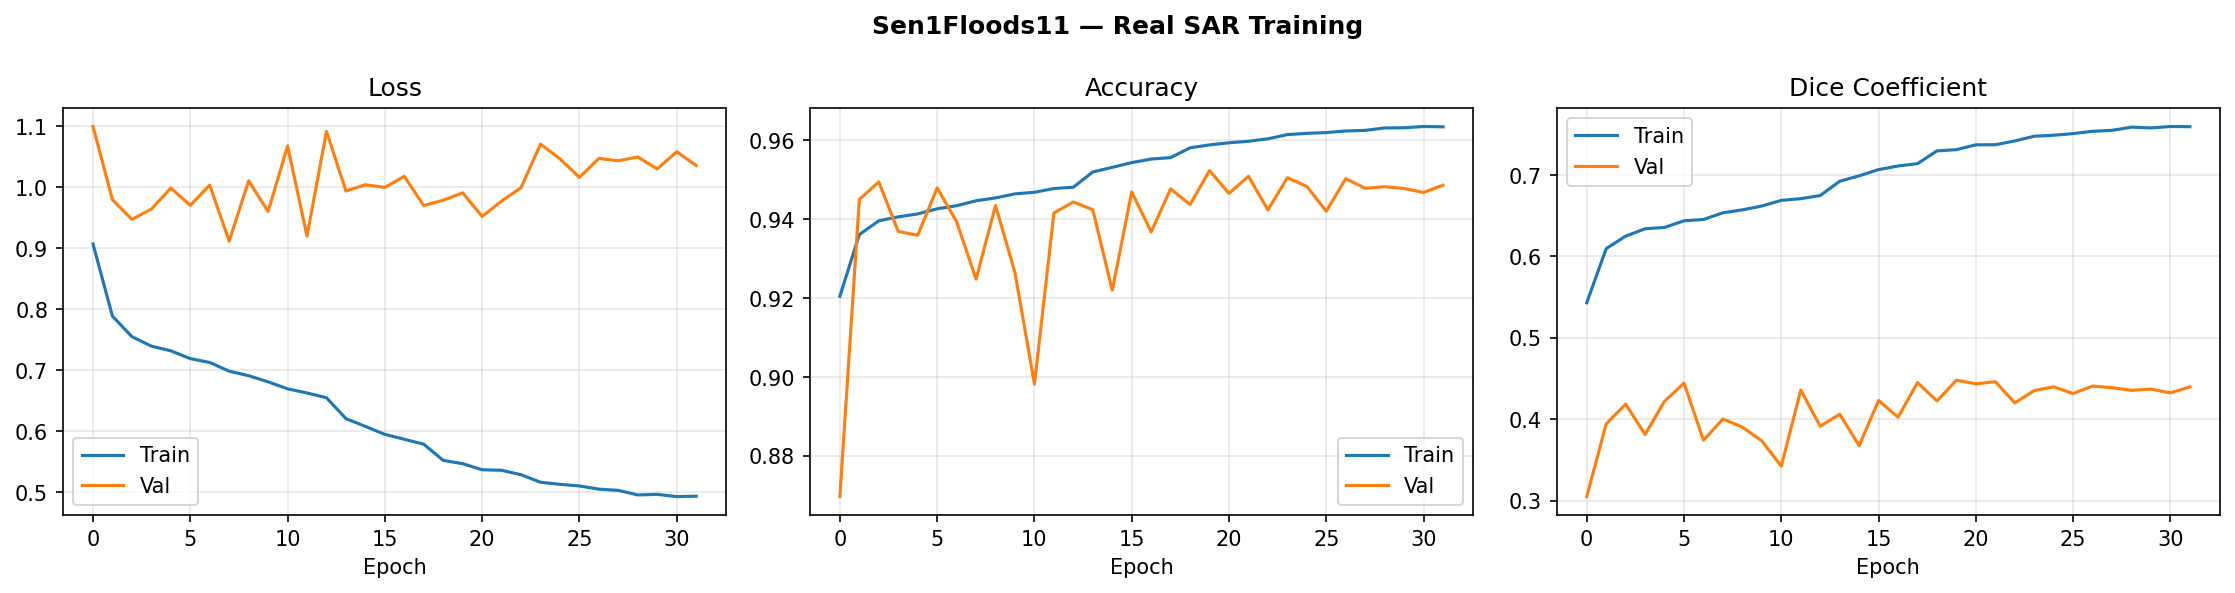

In [8]:
# FIX #9: guard against missing file if training cell was skipped
from IPython.display import Image as IPImage
chart_path = os.path.join(DRIVE_MODELS,'training_history.png')
if os.path.exists(chart_path):
    display(IPImage(chart_path))
else:
    print('No training chart found. Run Cell 7 first (or load a pre-trained model).')

## Cell 8 — Full evaluation + confusion matrix
Evaluates on the held-out test set. Saves confusion matrix, ROC, PR curves,
sample predictions and full metrics report to Drive.

  EVALUATION — HELD-OUT TEST SET (Real SAR)
153/153 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step
  Total pixels : 20,021,248
  Flood actual : 2,436,162  (12.2%)
  Flood pred   : 2,563,407  (12.8%)

  TP:1,961,972  FP:601,435  TN:16,983,651  FN:474,190
  Accuracy    : 0.9463
  Precision   : 0.7654
  Recall      : 0.8054
  F1 Score    : 0.7849
  IoU         : 0.6459
  Dice        : 0.7849
  ROC AUC     : 0.9578
  PR  AUC     : 0.8484


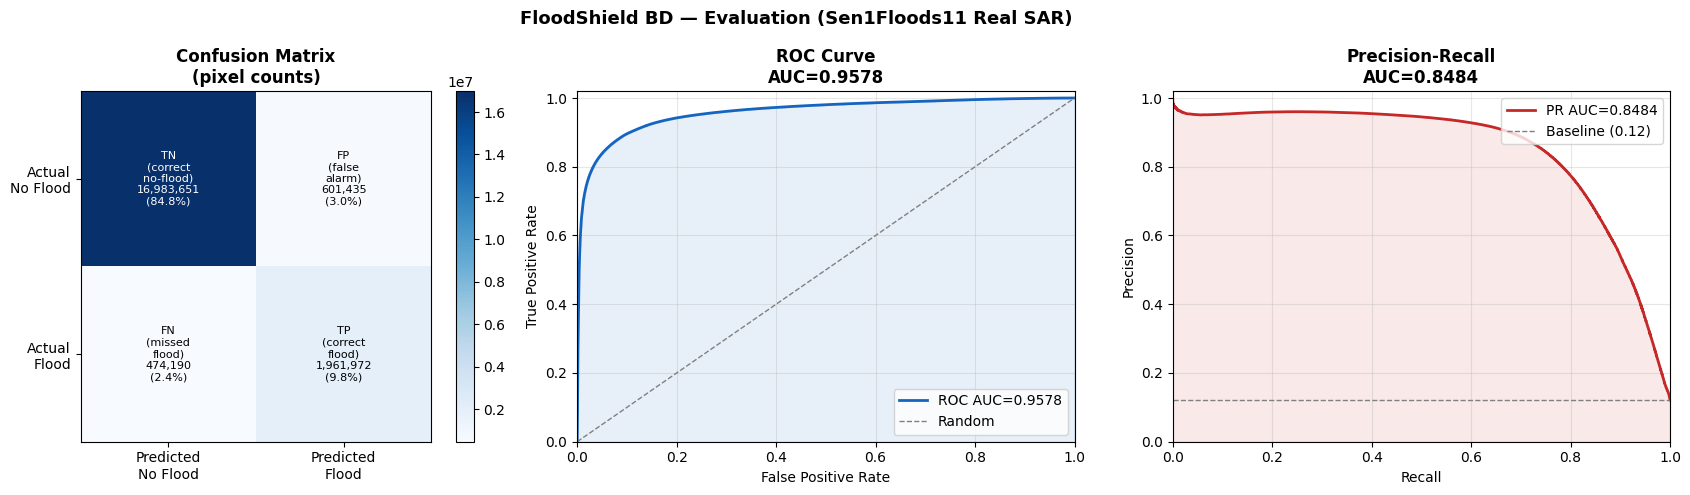

[DRIVE] Plot → /content/drive/MyDrive/FloodShield_Sen1/evaluation/confusion_matrix_and_curves.png


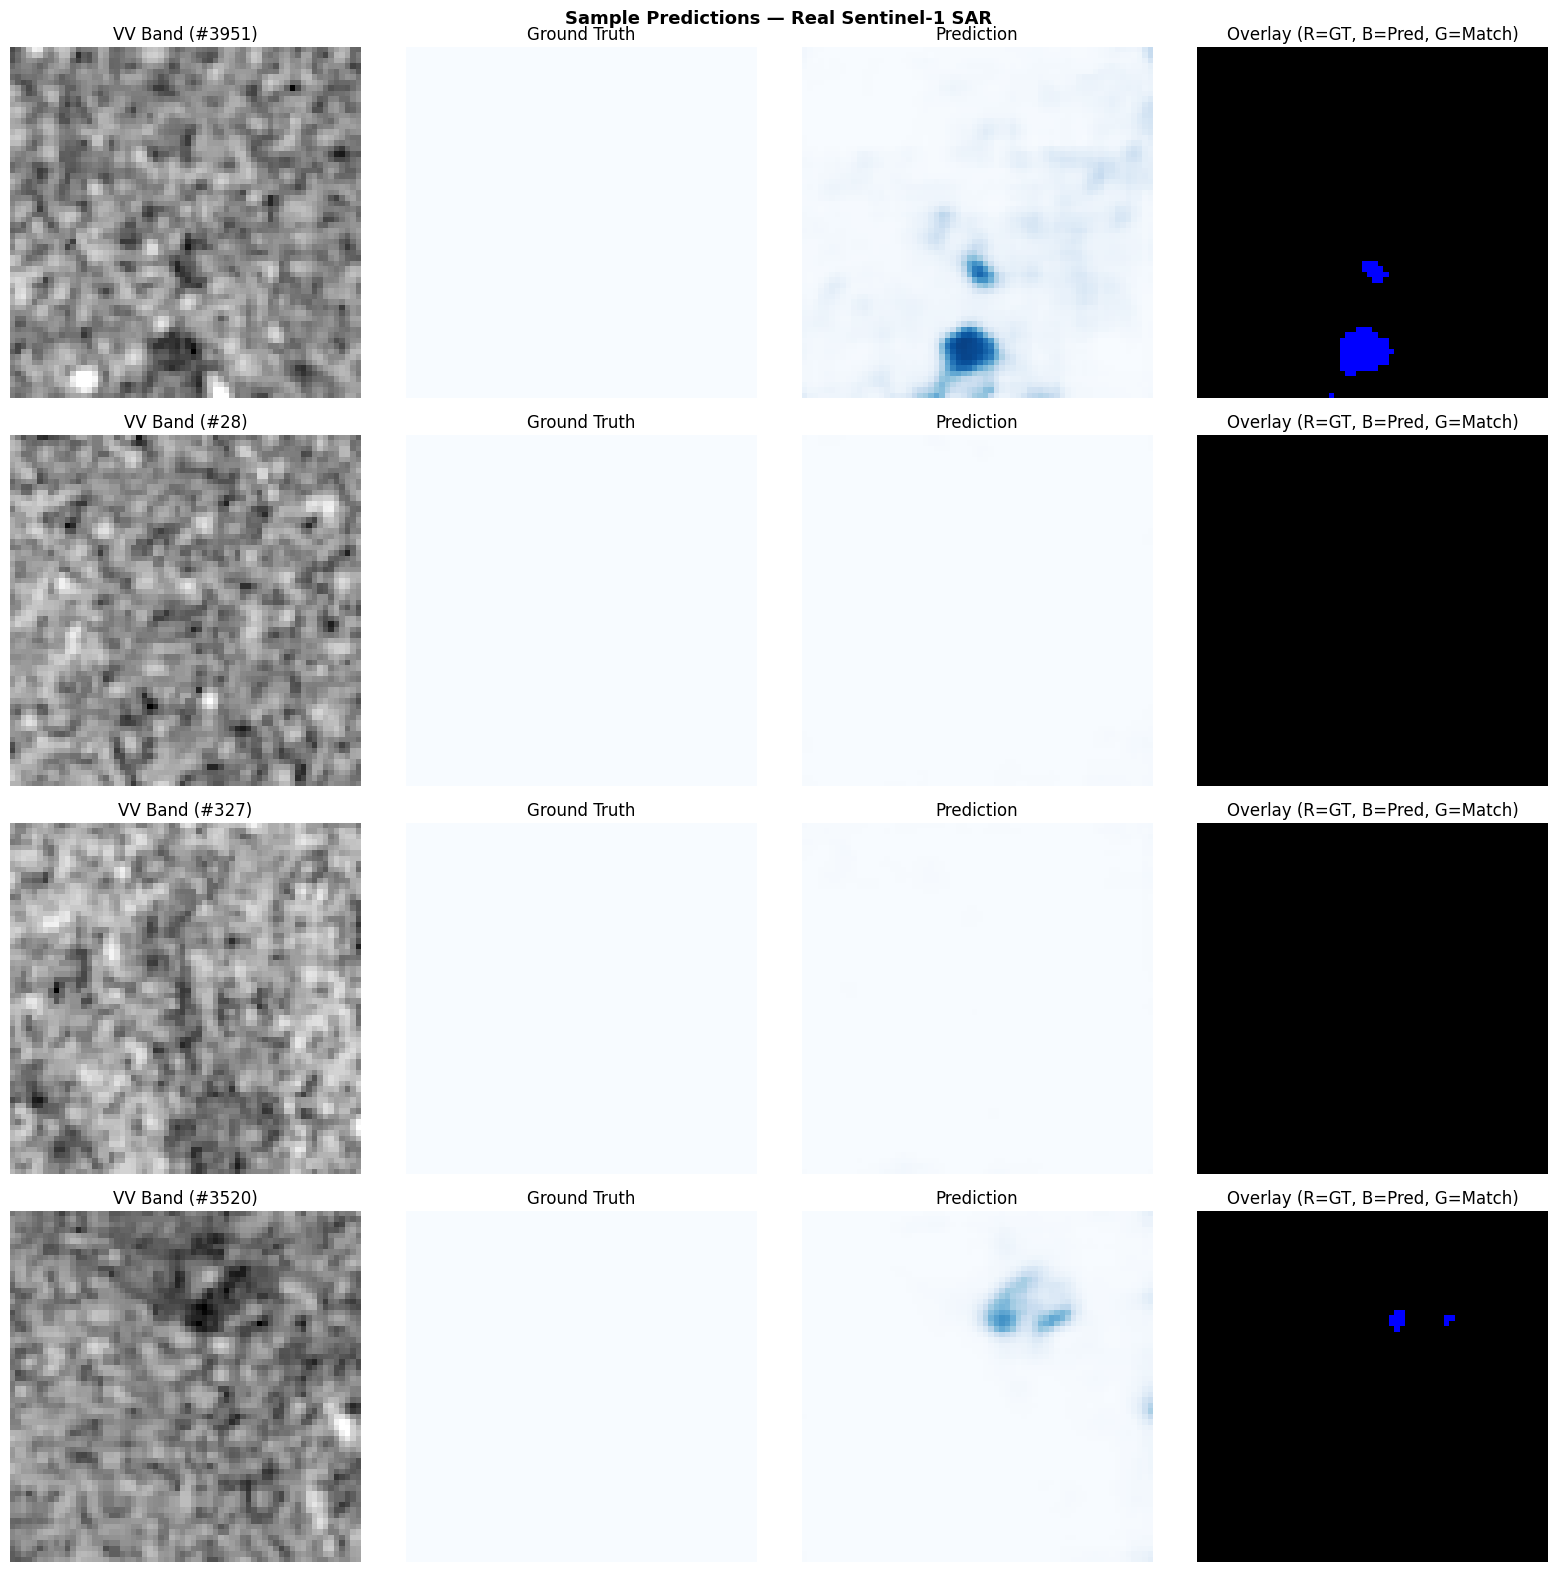

[DRIVE] Predictions → /content/drive/MyDrive/FloodShield_Sen1/evaluation/sample_predictions.png
[DRIVE] Metrics → /content/drive/MyDrive/FloodShield_Sen1/evaluation/
[DONE] Evaluation complete.


In [9]:
def evaluate_model(model, X_test, y_test):
    # FIX #10: guard against empty test set
    if len(X_test) == 0:
        print('[EVAL] ERROR: Test set is empty. Check Cell 5 data loading.')
        return None

    print('='*60)
    print('  EVALUATION — HELD-OUT TEST SET (Real SAR)')
    print('='*60)
    y_prob = model.predict(X_test, batch_size=BATCH_SIZE, verbose=1)
    y_true_flat = y_test.flatten().astype(np.int32)
    y_prob_flat = y_prob.flatten()
    y_pred_flat = (y_prob_flat > 0.5).astype(np.int32)
    total_px = len(y_true_flat)
    print(f'  Total pixels : {total_px:,}')
    print(f'  Flood actual : {y_true_flat.sum():,}  ({y_true_flat.mean()*100:.1f}%)')
    print(f'  Flood pred   : {y_pred_flat.sum():,}  ({y_pred_flat.mean()*100:.1f}%)')

    # FIX #12: renamed cm_result to avoid shadowing sklearn confusion_matrix function
    cm_result = confusion_matrix(y_true_flat, y_pred_flat)
    TN, FP, FN, TP = cm_result.ravel()
    print(f'\n  TP:{TP:,}  FP:{FP:,}  TN:{TN:,}  FN:{FN:,}')

    precision = TP/(TP+FP+1e-9); recall = TP/(TP+FN+1e-9)
    spec  = TN/(TN+FP+1e-9)
    f1    = 2*precision*recall/(precision+recall+1e-9)
    acc   = (TP+TN)/(TP+TN+FP+FN)
    iou   = TP/(TP+FP+FN+1e-9)
    dice  = 2*TP/(2*TP+FP+FN+1e-9)
    fpr, tpr, _ = roc_curve(y_true_flat, y_prob_flat)
    roc_auc = auc(fpr, tpr)
    prec_c, rec_c, _ = precision_recall_curve(y_true_flat, y_prob_flat)
    pr_auc = auc(rec_c, prec_c)

    print(f'  Accuracy    : {acc:.4f}')
    print(f'  Precision   : {precision:.4f}')
    print(f'  Recall      : {recall:.4f}')
    print(f'  F1 Score    : {f1:.4f}')
    print(f'  IoU         : {iou:.4f}')
    print(f'  Dice        : {dice:.4f}')
    print(f'  ROC AUC     : {roc_auc:.4f}')
    print(f'  PR  AUC     : {pr_auc:.4f}')

    # ── Confusion matrix + ROC + PR ──────────────────────────────
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle('FloodShield BD — Evaluation (Sen1Floods11 Real SAR)',
                 fontsize=13, fontweight='bold')
    ax = axes[0]
    cm_display = np.array([[TN,FP],[FN,TP]])
    cm_pct     = cm_display / cm_display.sum() * 100
    im = ax.imshow(cm_display, interpolation='nearest', cmap='Blues')
    ax.set_title('Confusion Matrix\n(pixel counts)', fontweight='bold')
    lbls = [['TN\n(correct\nno-flood)','FP\n(false\nalarm)'],
            ['FN\n(missed\nflood)',    'TP\n(correct\nflood)']]
    thresh = cm_display.max()/2.0
    for i,j in itertools.product(range(2),range(2)):
        col = 'white' if cm_display[i,j]>thresh else 'black'
        ax.text(j,i,f'{lbls[i][j]}\n{cm_display[i,j]:,}\n({cm_pct[i,j]:.1f}%)',
                ha='center',va='center',color=col,fontsize=8)
    ax.set_xticks([0,1]); ax.set_yticks([0,1])
    ax.set_xticklabels(['Predicted\nNo Flood','Predicted\nFlood'])
    ax.set_yticklabels(['Actual\nNo Flood','Actual\nFlood'])
    plt.colorbar(im, ax=ax, fraction=0.046)
    ax2 = axes[1]
    ax2.plot(fpr,tpr,color='#1565C0',lw=2,label=f'ROC AUC={roc_auc:.4f}')
    ax2.plot([0,1],[0,1],color='gray',lw=1,ls='--',label='Random')
    ax2.fill_between(fpr,tpr,alpha=0.1,color='#1565C0')
    ax2.set_xlim([0,1]); ax2.set_ylim([0,1.02])
    ax2.set_xlabel('False Positive Rate'); ax2.set_ylabel('True Positive Rate')
    ax2.set_title(f'ROC Curve\nAUC={roc_auc:.4f}', fontweight='bold')
    ax2.legend(loc='lower right'); ax2.grid(alpha=0.3)
    ax3 = axes[2]
    ax3.plot(rec_c,prec_c,color='#C62828',lw=2,label=f'PR AUC={pr_auc:.4f}')
    ax3.fill_between(rec_c,prec_c,alpha=0.1,color='#C62828')
    ax3.axhline(y=y_true_flat.mean(),color='gray',lw=1,ls='--',
                label=f'Baseline ({y_true_flat.mean():.2f})')
    ax3.set_xlim([0,1]); ax3.set_ylim([0,1.02])
    ax3.set_xlabel('Recall'); ax3.set_ylabel('Precision')
    ax3.set_title(f'Precision-Recall\nAUC={pr_auc:.4f}', fontweight='bold')
    ax3.legend(loc='upper right'); ax3.grid(alpha=0.3)
    plt.tight_layout()
    os.makedirs(DRIVE_EVAL, exist_ok=True)
    cm_path = os.path.join(DRIVE_EVAL,'confusion_matrix_and_curves.png')
    plt.savefig(cm_path, dpi=150, bbox_inches='tight')
    plt.show()   # inline display in Colab
    plt.close()
    print(f'[DRIVE] Plot → {cm_path}')

    # ── Sample predictions ────────────────────────────────────────
    n = min(4, len(X_test))
    fig, axes = plt.subplots(n, 4, figsize=(16, 4*n))
    if n == 1: axes = axes[np.newaxis,:]
    fig.suptitle('Sample Predictions — Real Sentinel-1 SAR',
                 fontsize=13, fontweight='bold')
    for row, si in enumerate(np.random.choice(len(X_test), n, replace=False)):
        axes[row,0].imshow(X_test[si,:,:,0], cmap='gray')
        axes[row,0].set_title(f'VV Band (#{si})')
        axes[row,1].imshow(y_test[si,:,:,0], cmap='Blues', vmin=0, vmax=1)
        axes[row,1].set_title('Ground Truth')
        axes[row,2].imshow(y_prob[si,:,:,0], cmap='Blues', vmin=0, vmax=1)
        axes[row,2].set_title('Prediction')
        # FIX #11: explicit float32 cast for overlay channels
        ov = np.zeros((*X_test[si,:,:,0].shape, 3), dtype=np.float32)
        ov[:,:,0] = y_test[si,:,:,0].astype(np.float32)
        ov[:,:,2] = (y_prob[si,:,:,0] > 0.5).astype(np.float32)
        ov[:,:,1] = ov[:,:,0] * ov[:,:,2]
        axes[row,3].imshow(ov)
        axes[row,3].set_title('Overlay (R=GT, B=Pred, G=Match)')
        for c in range(4): axes[row,c].axis('off')
    plt.tight_layout()
    sp_path = os.path.join(DRIVE_EVAL,'sample_predictions.png')
    plt.savefig(sp_path, dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()
    print(f'[DRIVE] Predictions → {sp_path}')

    # ── Save metrics ──────────────────────────────────────────────
    report = classification_report(y_true_flat, y_pred_flat,
                                   target_names=['No Flood','Flood'])
    metrics = {
        'dataset':'Sen1Floods11 hand-labeled real Sentinel-1 SAR',
        'accuracy':round(float(acc),6),
        'precision':round(float(precision),6),
        'recall':round(float(recall),6),
        'specificity':round(float(spec),6),
        'f1_score':round(float(f1),6),
        'iou':round(float(iou),6),
        'dice_coef':round(float(dice),6),
        'roc_auc':round(float(roc_auc),6),
        'pr_auc':round(float(pr_auc),6),
        'confusion_matrix':{'TP':int(TP),'FP':int(FP),'TN':int(TN),'FN':int(FN)},
        'total_pixels':int(total_px),
        'test_tiles':int(len(X_test)),
        'tile_size':IMAGE_SIZE,
        'timestamp':datetime.now().isoformat(),
        'citation':'Bonafilia et al., Sen1Floods11, IEEE/CVF CVPR Workshops 2020'
    }
    with open(os.path.join(DRIVE_EVAL,'metrics.json'),'w') as f:
        json.dump(metrics, f, indent=2)
    with open(os.path.join(DRIVE_EVAL,'classification_report.txt'),'w') as f:
        f.write('FLOODSHIELD BD — EVALUATION REPORT\n')
        f.write('Dataset: Sen1Floods11 (real Sentinel-1 SAR)\n'+'='*55+'\n\n')
        for k,v in metrics.items():
            if k not in ('dataset','citation','confusion_matrix','timestamp'):
                f.write(f'{k:15s}: {v}\n')
        f.write(f'\nCM: TP={TP:,} FP={FP:,} TN={TN:,} FN={FN:,}\n\n')
        f.write('Classification Report:\n'+report)
    print(f'[DRIVE] Metrics → {DRIVE_EVAL}/')
    print('[DONE] Evaluation complete.')
    return metrics

metrics = evaluate_model(model, X_test, y_test)

## Cell 9 — Final summary & Drive file listing

In [10]:
mpath = os.path.join(DRIVE_EVAL,'metrics.json')
if os.path.exists(mpath):
    with open(mpath) as f: m = json.load(f)
    print('='*55)
    print('  FLOODSHIELD BD — FINAL RESULTS')
    print('  Sen1Floods11 (Real Sentinel-1 SAR)')
    print('='*55)
    print(f'  Accuracy    : {m["accuracy"]:.4f}  ({m["accuracy"]*100:.2f}%)')
    print(f'  Precision   : {m["precision"]:.4f}')
    print(f'  Recall      : {m["recall"]:.4f}')
    print(f'  F1 Score    : {m["f1_score"]:.4f}')
    print(f'  IoU         : {m["iou"]:.4f}')
    print(f'  Dice        : {m["dice_coef"]:.4f}')
    print(f'  ROC AUC     : {m["roc_auc"]:.4f}')
    print(f'  PR  AUC     : {m["pr_auc"]:.4f}')
    cm = m['confusion_matrix']
    print(f'  TP:{cm["TP"]:,}  FP:{cm["FP"]:,}  TN:{cm["TN"]:,}  FN:{cm["FN"]:,}')
    print('='*55)
    print(f'\n  Files in {DRIVE_BASE}/')
    for root,dirs,files in os.walk(DRIVE_BASE):
        dirs.sort(); files.sort()
        lvl = root.replace(DRIVE_BASE,'').count(os.sep)
        ind = '  '*(lvl+1)
        if lvl > 0: print(f'{ind}📁 {os.path.basename(root)}/')
        for fn in files:
            sz = os.path.getsize(os.path.join(root,fn))/1024
            print(f'{ind}  📄 {fn}  ({sz:.0f} KB)')
else:
    print('No metrics found — run Cell 8 first.')

  FLOODSHIELD BD — FINAL RESULTS
  Sen1Floods11 (Real Sentinel-1 SAR)
  Accuracy    : 0.9463  (94.63%)
  Precision   : 0.7654
  Recall      : 0.8054
  F1 Score    : 0.7849
  IoU         : 0.6459
  Dice        : 0.7849
  ROC AUC     : 0.9578
  PR  AUC     : 0.8484
  TP:1,961,972  FP:601,435  TN:16,983,651  FN:474,190

  Files in /content/drive/MyDrive/FloodShield_Sen1/
    📁 evaluation/
      📄 classification_report.txt  (1 KB)
      📄 confusion_matrix_and_curves.png  (155 KB)
      📄 metrics.json  (1 KB)
      📄 sample_predictions.png  (178 KB)
    📁 models/
      📄 flood_best.keras  (5929 KB)
      📄 flood_final.keras  (5929 KB)
      📄 training_history.png  (116 KB)
    📁 sen1floods11_data/
      📁 LabelHand/
        📄 Bolivia_103757_LabelHand.tif  (7 KB)
        📄 Bolivia_129334_LabelHand.tif  (13 KB)
        📄 Bolivia_195474_LabelHand.tif  (2 KB)
        📄 Bolivia_23014_LabelHand.tif  (5 KB)
        📄 Bolivia_233925_LabelHand.tif  (9 KB)
        📄 Bolivia_242570_LabelHand.tif  (10 